## Ekstrakcja topologii

### Importy

In [ ]:
from __future__ import annotations

import cv2
import numpy as np
from pathlib import Path

from skimage.morphology import skeletonize
from coronary_analysis.utils import show_image, get_device
from skimage import morphology, measure

import torch
from coronary_analysis.models.segmentation import CoronaryUNetPP
from coronary_analysis.transforms import get_val_transforms

### Konfiguracja zmiennych środowiskowych

In [ ]:
USE_GROUND_TRUTH: bool = True
SAMPLE_ID: int = 112
DCA1_DIR = Path("raw_datasets/DCA1/Database_134_Angiograms/test")
MODEL_PATH = Path("../models/best_coronary_unet.pth")
IMG_SIZE: int = 250
THRESHOLD: float = 0.5
MIN_OBJECT_SIZE: int = 50
MAX_HOLE_SIZE: int = 50
CLOSING_DISK_RADIUS: float = 2
MIN_BRANCH_LENGTH = 15
COLLINEARITY_THRESHOLD = 30
DIRECTION_STEPS = 8
BRANCH_IDX = 4

device = get_device()

## Wczytanie danych

### Załadowanie modelu

In [ ]:
model = CoronaryUNetPP(encoder_name="resnet34").to(device)
model.load_state_dict(
    torch.load(str(MODEL_PATH), map_location=device, weights_only=True)
)
model.eval()

CoronaryUNet(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): Ba

### Wczytanie pliku PGM w skali szarości

In [705]:
def _load_pgm(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise FileNotFoundError(f"File not found: {path}")

    return image

### Wczytanie obrazu oraz binaryzacja

In [706]:
def load_sample(
    sample_id: int, ground_truth: bool = True
) -> tuple[np.ndarray, np.ndarray]:
    image = _load_pgm(DCA1_DIR / f"{sample_id}.pgm")

    if ground_truth:
        raw = _load_pgm(DCA1_DIR / f"{sample_id}_gt.pgm")
        mask = (raw > 0).astype(np.uint8)
    else:
        mask = _predict_mask(image, model)

    return image, mask

### Uruchomienie modelu segmentacji i zwrócenie maski binarnej

In [707]:
def _predict_mask(image: np.ndarray, model: torch.nn.Module) -> np.ndarray:
    transform = get_val_transforms(IMG_SIZE)
    augmented = transform(image=image, mask=np.zeros_like(image))

    img_tensor = (
        torch.from_numpy(augmented["image"]).float().unsqueeze(0).unsqueeze(0) / 255.0
    ).to(device)

    with torch.no_grad():
        probs = model.predict_proba(img_tensor)
        pred = (probs > THRESHOLD).float()

    pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)

    h, w = image.shape[:2]
    if pred_np.shape != (h, w):
        pred_np = cv2.resize(pred_np, (w, h), interpolation=cv2.INTER_NEAREST)

    return pred_np

### Wizualizacja wczytanych danych

Image: shape=(300, 300), dtype=uint8
Mask: shape=(300, 300), dtype=uint8, unique=[0 1]


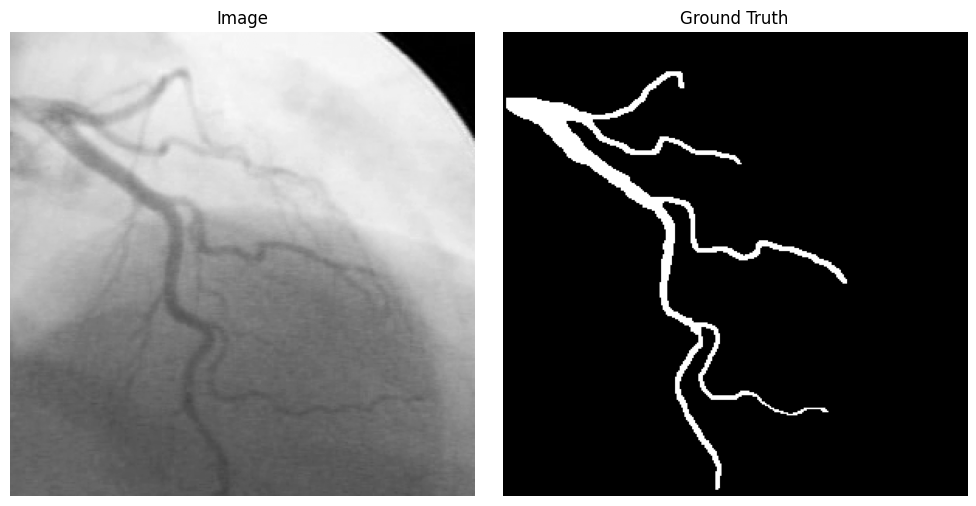

In [708]:
image, raw_mask = load_sample(SAMPLE_ID, ground_truth=USE_GROUND_TRUTH)

source_label = "Ground Truth" if USE_GROUND_TRUTH else "Model Prediction"

print(f"Image: shape={image.shape}, dtype={image.dtype}")
print(
    f"Mask: shape={raw_mask.shape}, dtype={raw_mask.dtype}, "
    f"unique={np.unique(raw_mask)}"
)

show_image(image, raw_mask, titles=["Image", source_label])

### Wstępne przetwarzanie danych

In [709]:
def clean_mask(mask: np.ndarray) -> dict[str, np.ndarray]:
    binary = mask.astype(bool)

    closed = (
        morphology.closing(binary, morphology.disk(CLOSING_DISK_RADIUS))
        if CLOSING_DISK_RADIUS > 0
        else binary
    )

    no_holes = morphology.remove_small_holes(closed, max_size=MAX_HOLE_SIZE)

    final = morphology.remove_small_objects(no_holes, max_size=MIN_OBJECT_SIZE)

    return {
        "input": binary,
        "closed": closed,
        "no_holes": no_holes,
        "final": final,
    }

### Liczba połączonych elementów w masce

In [710]:
def _count_components(mask: np.ndarray) -> int:
    return measure.label(mask).max()

### Wizualizacja przeprocesowanych danych

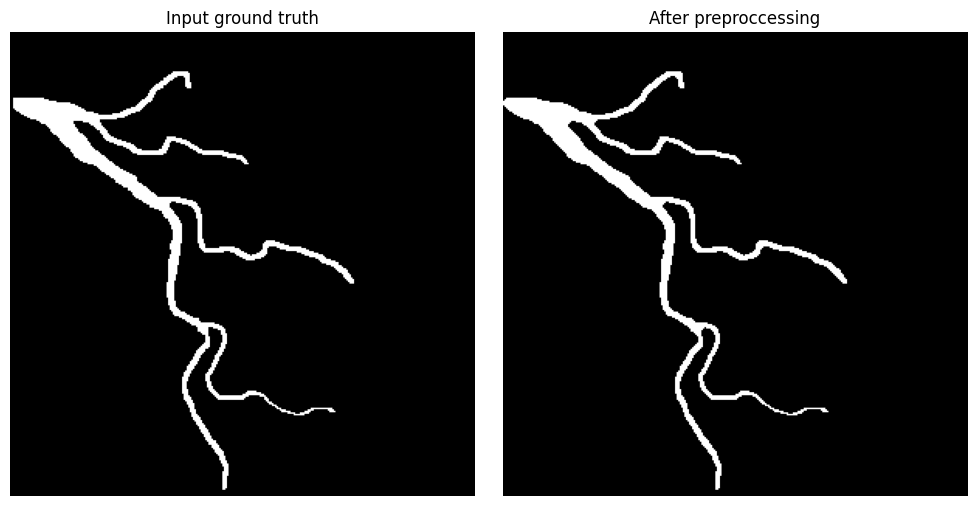

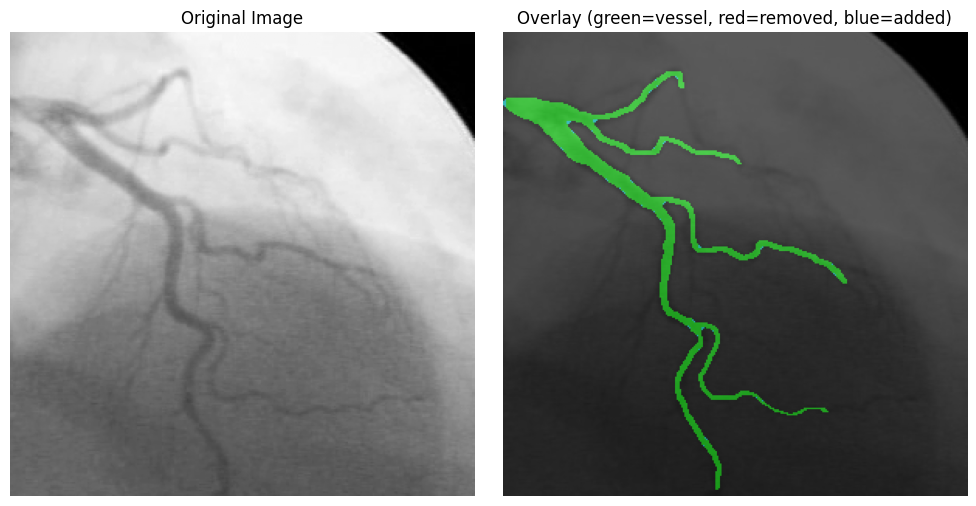

In [711]:
stages = clean_mask(raw_mask)
mask_clean = stages["final"]

removed = stages["input"] & ~stages["final"]
added = stages["final"] & ~stages["input"]

overlay = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4
overlay[stages["final"], 1] += 0.5
overlay[removed, 0] += 0.5
overlay[added, 2] += 0.5
overlay = np.clip(overlay, 0, 1)

show_image(
    stages["input"].astype(np.uint8),
    stages["final"].astype(np.uint8),
    titles=[
        "Input ground truth" if USE_GROUND_TRUTH else "Input segmentation",
        "After preproccessing",
    ],
)

show_image(
    image,
    overlay,
    titles=["Original Image", "Overlay (green=vessel, red=removed, blue=added)"],
    cmap=["gray", None],
)

## Szkieletyzacja

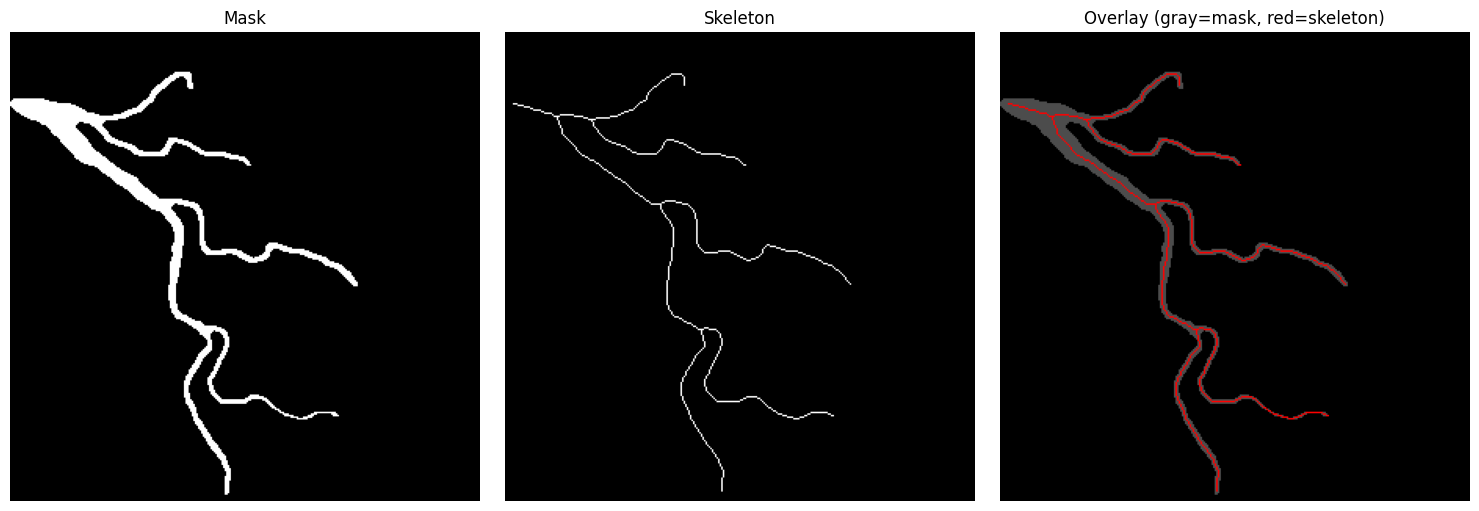

In [712]:
skeleton = skeletonize(mask_clean)

overlay = np.zeros((*mask_clean.shape, 3))
overlay[mask_clean, :] = [0.3, 0.3, 0.3]
overlay[skeleton, :] = [1, 0, 0]

show_image(
    mask_clean.astype(np.uint8),
    skeleton.astype(np.uint8),
    overlay,
    titles=["Mask", "Skeleton", "Overlay (gray=mask, red=skeleton)"],
    cmap=["gray", "gray", None],
)

### Rysowanie punktów

In [713]:
def _draw_points(
    base: np.ndarray, points: np.ndarray, color: tuple, radius: int = 3
) -> np.ndarray:
    img = base.copy()

    for r, c in points:
        cv2.circle(img, (int(c), int(r)), radius, color, -1)

    return img

### Klasyfikacja pikseli

In [714]:
def classify_skeleton_pixels(skel: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    kernel = np.array([[1, 1, 1], [1, 10, 1], [1, 1, 1]], dtype=np.uint8)

    filtered = cv2.filter2D(skel.astype(np.uint8), -1, kernel)
    endpoints = np.argwhere(filtered == 11)
    junctions = np.argwhere(filtered >= 13)

    return endpoints, junctions


endpoints, junctions = classify_skeleton_pixels(skeleton)
print(f"Punkty końcowe : {len(endpoints)}")
print(f"Rozgałęzienia  : {len(junctions)}")

Punkty końcowe : 6
Rozgałęzienia  : 15


### Wizualizacja punktów końcowych

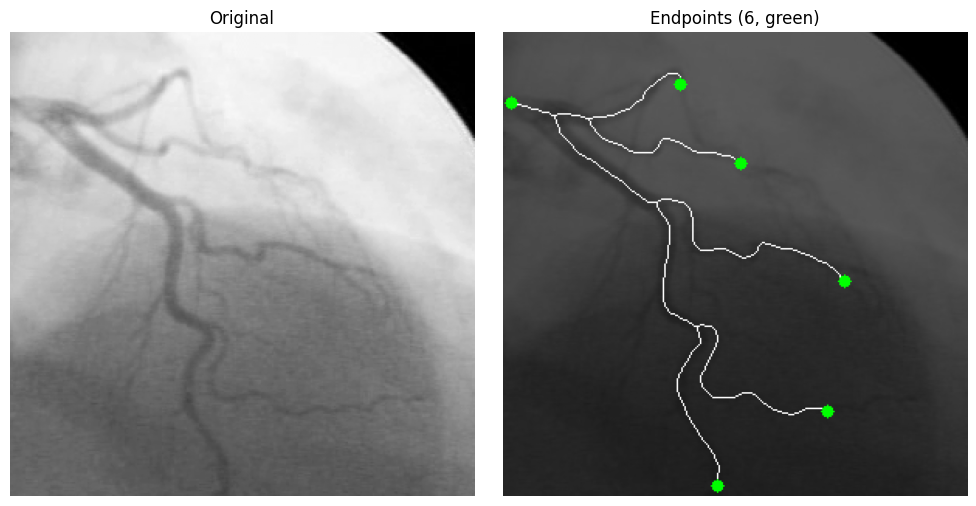

In [715]:
vis_ep = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4
vis_ep[skeleton, :] = [1, 1, 1]
vis_ep = _draw_points(vis_ep, endpoints, (0, 1, 0), radius=4)

show_image(
    image,
    vis_ep,
    titles=["Original", f"Endpoints ({len(endpoints)}, green)"],
    cmap=["gray", None],
)

### Wizualizacja rozgałęzień

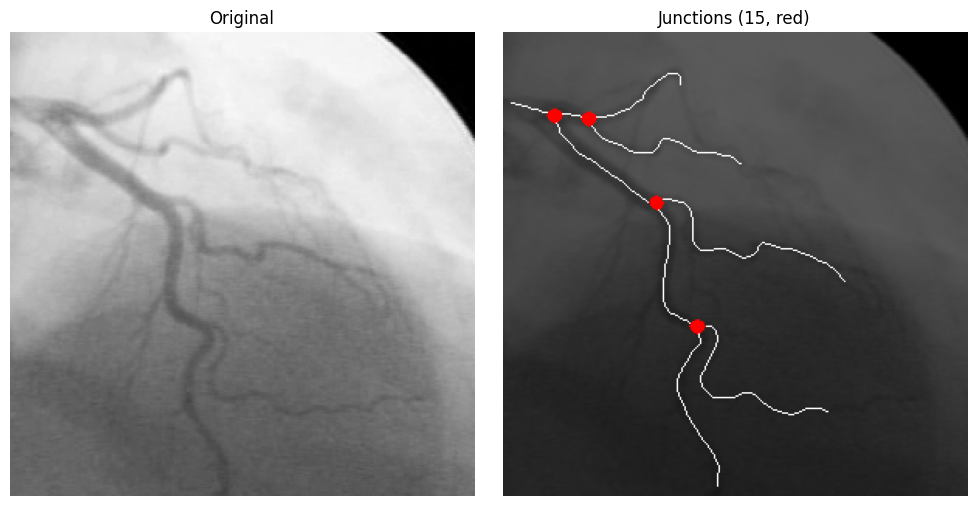

In [716]:
vis_junc = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4
vis_junc[skeleton, :] = [1, 1, 1]
vis_junc = _draw_points(vis_junc, junctions, (1, 0, 0), radius=4)

show_image(
    image,
    vis_junc,
    titles=["Original", f"Junctions ({len(junctions)}, red)"],
    cmap=["gray", None],
)

### Pruning

In [717]:
def prune_skeleton(skel: np.ndarray) -> np.ndarray:
    pruned = skel.copy()

    while True:
        eps, _ = classify_skeleton_pixels(pruned)
        if len(eps) == 0:
            break

        changed = False
        for r, c in eps:
            branch = [(r, c)]
            cur_r, cur_c = r, c

            for _ in range(MIN_BRANCH_LENGTH):
                found = False
                for dr in (-1, 0, 1):
                    for dc in (-1, 0, 1):
                        if dr == 0 and dc == 0:
                            continue
                        nr, nc = cur_r + dr, cur_c + dc
                        if (
                            0 <= nr < pruned.shape[0]
                            and 0 <= nc < pruned.shape[1]
                            and pruned[nr, nc]
                            and (nr, nc) not in branch
                        ):
                            branch.append((nr, nc))
                            cur_r, cur_c = nr, nc
                            found = True
                            break
                    if found:
                        break
                if not found:
                    break

            if len(branch) < MIN_BRANCH_LENGTH:
                for pr, pc in branch:
                    pruned[pr, pc] = False
                changed = True

        if not changed:
            break

    return pruned


skeleton_pruned = prune_skeleton(skeleton)
ep_pruned, junc_pruned = classify_skeleton_pixels(skeleton_pruned)

print("─" * 55)
print(f"{'':30} {'Before':>8} {'After':>8}")
print("─" * 55)
print(f"{'Endpoints':<30} {len(endpoints):>8} {len(ep_pruned):>8}")
print(f"{'Junctions':<30} {len(junctions):>8} {len(junc_pruned):>8}")
print(
    f"{'Skeleton pixels':<30} {int(skeleton.sum()):>8} {int(skeleton_pruned.sum()):>8}"
)
print("─" * 55)

───────────────────────────────────────────────────────
                                 Before    After
───────────────────────────────────────────────────────
Endpoints                             6        6
Junctions                            15       15
Skeleton pixels                     762      762
───────────────────────────────────────────────────────


### Wizualizacja pruningu

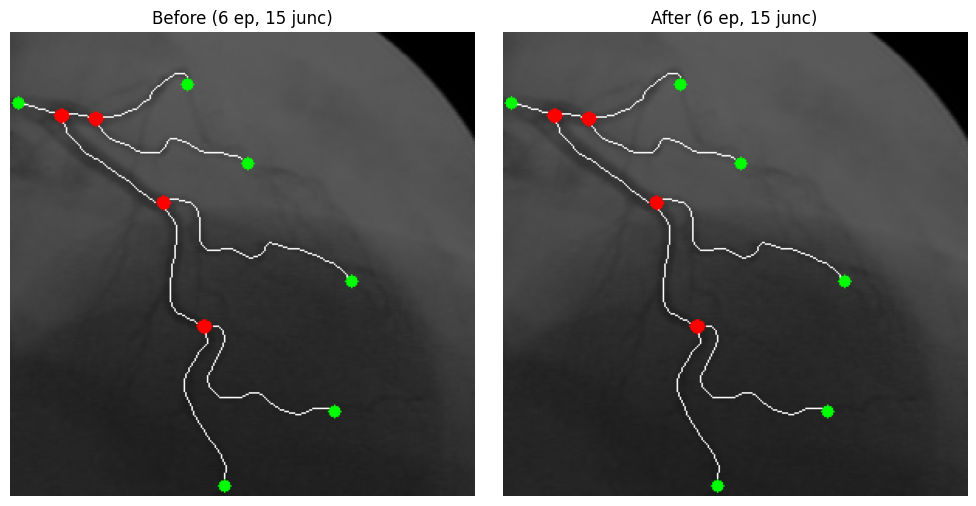

In [718]:
vis_before = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4
vis_before[skeleton, :] = [1, 1, 1]
vis_before = _draw_points(vis_before, endpoints, (0, 1, 0), radius=4)
vis_before = _draw_points(vis_before, junctions, (1, 0, 0), radius=4)

vis_after = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4
vis_after[skeleton_pruned, :] = [1, 1, 1]
vis_after = _draw_points(vis_after, ep_pruned, (0, 1, 0), radius=4)
vis_after = _draw_points(vis_after, junc_pruned, (1, 0, 0), radius=4)

show_image(
    vis_before,
    vis_after,
    titles=[
        f"Before ({len(endpoints)} ep, {len(junctions)} junc)",
        f"After ({len(ep_pruned)} ep, {len(junc_pruned)} junc)",
    ],
    cmap=[None, None],
)

### Budowa grafu

In [719]:
from skan import Skeleton, summarize

skel_obj = Skeleton(skeleton_pruned)
branch_data = summarize(skel_obj, separator="_")

print("=== Branch Data ===")
print(branch_data.to_string())
print(f"\nBranches: {len(branch_data)}")
print(f"Cycles:   {len(branch_data[branch_data['branch_type'] == 3])}")

print("\n=== Example: branch path ===")
path = skel_obj.path_coordinates(BRANCH_IDX)
print(
    f"Pixels: {len(path)}, start=({path[0][0]:.0f}, {path[0][1]:.0f}), end=({path[-1][0]:.0f}, {path[-1][1]:.0f})"
)

print("\n=== Topology ===")
print(f"Total vessel length     : {branch_data['branch_distance'].sum():.0f} px")
print(f"Longest branch          : {branch_data['branch_distance'].max():.0f} px")
print(f"Shortest branch         : {branch_data['branch_distance'].min():.0f} px")
print(
    f"Mean tortuosity         : {(branch_data['branch_distance'] / branch_data['euclidean_distance'].clip(1)).mean():.3f}"
)
print(f"Junction-to-junction    : {len(branch_data[branch_data['branch_type'] == 2])}")
print(f"Junction-to-endpoint    : {len(branch_data[branch_data['branch_type'] == 1])}")
print(f"Endpoint-to-endpoint    : {len(branch_data[branch_data['branch_type'] == 0])}")

=== Branch Data ===
   skeleton_id  node_id_src  node_id_dst  branch_distance  branch_type  mean_pixel_value  stdev_pixel_value  image_coord_src_0  image_coord_src_1  image_coord_dst_0  image_coord_dst_1  coord_src_0  coord_src_1  coord_dst_0  coord_dst_1  euclidean_distance
0            0           22          117        78.597980            1               1.0                0.0                 34                114                 56                 55           34          114           56           55           62.968246
1            0           37           88        31.313708            1               1.0                0.0                 46                  5                 54                 33           46            5           54           33           29.120440
2            0           88          117        23.656854            2               1.0                0.0                 54                 33                 56                 55           54           33   

### Wizualizacja

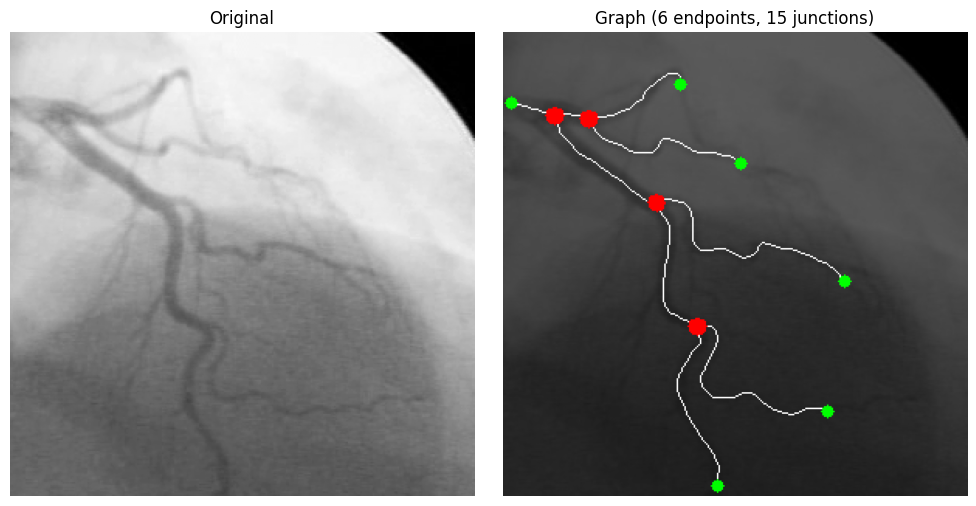

In [720]:
vis = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4

for idx in range(len(branch_data)):
    path_coords = skel_obj.path_coordinates(idx)
    for k in range(len(path_coords) - 1):
        cv2.line(
            vis,
            (int(path_coords[k][1]), int(path_coords[k][0])),
            (int(path_coords[k + 1][1]), int(path_coords[k + 1][0])),
            (1, 1, 1),
            1,
        )

vis = _draw_points(vis, ep_pruned, (0, 1, 0), radius=4)
vis = _draw_points(vis, junc_pruned, (1, 0, 0), radius=5)

show_image(
    image,
    vis,
    titles=[
        "Original",
        f"Graph ({len(ep_pruned)} endpoints, {len(junc_pruned)} junctions)",
    ],
    cmap=["gray", None],
)

In [721]:
from scipy.ndimage import distance_transform_edt

dist_map = distance_transform_edt(mask_clean)

path = skel_obj.path_coordinates(BRANCH_IDX)
diameters = np.array([2 * dist_map[int(r), int(c)] for r, c in path])

print(f"Branch {BRANCH_IDX}: {len(path)} pixels")
print(f"  Min diameter: {diameters.min():.1f} px")
print(f"  Max diameter: {diameters.max():.1f} px")
print(f"  Mean diameter: {diameters.mean():.1f} px")

Branch 4: 105 pixels
  Min diameter: 2.0 px
  Max diameter: 8.9 px
  Mean diameter: 4.0 px


### Wizualizacja

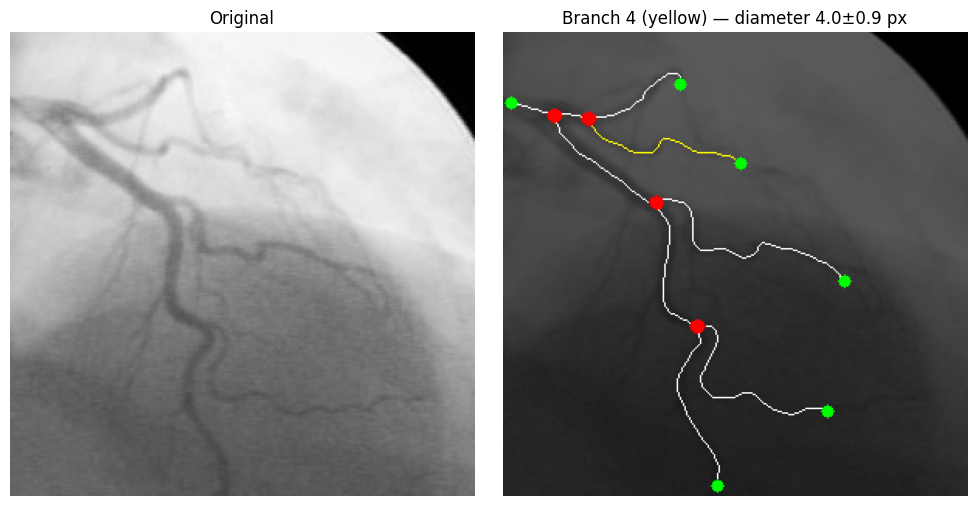

In [722]:
vis = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4

for idx in range(len(branch_data)):
    p = skel_obj.path_coordinates(idx)
    color = (1, 1, 0) if idx == BRANCH_IDX else (1, 1, 1)
    thickness = 1 if idx == BRANCH_IDX else 1
    for k in range(len(p) - 1):
        cv2.line(
            vis,
            (int(p[k][1]), int(p[k][0])),
            (int(p[k + 1][1]), int(p[k + 1][0])),
            color,
            thickness,
        )

vis = _draw_points(vis, ep_pruned, (0, 1, 0), radius=4)
vis = _draw_points(vis, junc_pruned, (1, 0, 0), radius=4)

show_image(
    image,
    vis,
    titles=[
        "Original",
        f"Branch {BRANCH_IDX} (yellow) — diameter {diameters.mean():.1f}±{diameters.std():.1f} px",
    ],
    cmap=["gray", None],
)

### Krawędź jako piksele

In [723]:
path = skel_obj.path_coordinates(BRANCH_IDX)

for r, c in path:
    print(f"  ({int(r):>3}, {int(c):>3})")

  ( 56,  55)
  ( 57,  55)
  ( 58,  56)
  ( 59,  56)
  ( 60,  56)
  ( 61,  57)
  ( 62,  58)
  ( 63,  59)
  ( 64,  59)
  ( 65,  60)
  ( 66,  61)
  ( 67,  62)
  ( 68,  63)
  ( 69,  64)
  ( 69,  65)
  ( 70,  66)
  ( 70,  67)
  ( 71,  68)
  ( 71,  69)
  ( 71,  70)
  ( 72,  71)
  ( 72,  72)
  ( 72,  73)
  ( 73,  74)
  ( 73,  75)
  ( 73,  76)
  ( 74,  77)
  ( 75,  78)
  ( 75,  79)
  ( 76,  80)
  ( 77,  81)
  ( 77,  82)
  ( 77,  83)
  ( 78,  84)
  ( 78,  85)
  ( 78,  86)
  ( 78,  87)
  ( 78,  88)
  ( 78,  89)
  ( 78,  90)
  ( 78,  91)
  ( 78,  92)
  ( 78,  93)
  ( 78,  94)
  ( 78,  95)
  ( 78,  96)
  ( 77,  97)
  ( 76,  98)
  ( 75,  99)
  ( 74, 100)
  ( 73, 100)
  ( 72, 101)
  ( 71, 101)
  ( 70, 102)
  ( 69, 103)
  ( 69, 104)
  ( 69, 105)
  ( 69, 106)
  ( 69, 107)
  ( 70, 108)
  ( 70, 109)
  ( 70, 110)
  ( 71, 111)
  ( 71, 112)
  ( 71, 113)
  ( 72, 114)
  ( 72, 115)
  ( 73, 116)
  ( 74, 117)
  ( 74, 118)
  ( 75, 119)
  ( 75, 120)
  ( 76, 121)
  ( 77, 122)
  ( 77, 123)
  ( 77, 124)
  ( 78, 125)